In [1]:
import os
import sys

import numpy as np
import pandas as pd

import warnings

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath(os.path.join("modelling", '../..')))

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

from sklearn.decomposition import PCA, NMF, KernelPCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [2]:
SEED = 42
PLOT_DPI = 100

DATA_FILE = "../../datasets/Skoltech_Anomaly_Benchmark/preprocessed_skab_dataset_set2.csv"

In [3]:
dataframe = pd.read_csv(DATA_FILE)
dataframe.set_index(pd.to_datetime(dataframe.datetime), drop=True, inplace=True)
dataframe.drop(columns=["datetime"], inplace=True)
dataframe.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,AccelerometerRMS_Fluctuation,Temperature_Fluctuation,Thermocouple_Fluctuation,Volume Flow RateRMS_Fluctuation,Hydraulic_Power_Fluctuation,Electrical_Power_Fluctuation,anomaly,description
datetime,,,,,,,,,,,,,,,,,,,,,
2020-02-08 13:30:47,0.202394,0.275154,2.16975,1.402774,90.6454,26.8508,238.852,122.664,110.082728,0.011436,...,0.205773,0.010205,0.000339,0.06556,0.004268,0.23928,42.844684,64.762931,0.0,No Anomaly
2020-02-08 13:30:48,0.203153,0.277857,2.07999,0.746920,90.7978,26.8639,227.943,122.338,109.588508,0.006105,...,0.225304,0.005911,0.000339,0.06556,0.004268,0.23928,42.844684,64.762931,0.0,No Anomaly
2020-02-08 13:30:49,0.203153,0.277857,2.07999,0.746920,90.7978,26.8639,227.943,122.338,109.588508,0.006105,...,0.225304,0.005911,0.000339,0.06556,0.004268,0.23928,42.844684,64.762931,0.0,No Anomaly
2020-02-08 13:30:50,0.202054,0.275790,2.52577,1.402774,90.7730,26.8603,223.486,121.338,88.482324,0.011561,...,0.189188,0.009251,0.000339,0.06556,0.004268,0.23928,42.844684,64.762931,0.0,No Anomaly
2020-02-08 13:30:51,0.203595,0.278101,2.49742,1.074847,90.8424,26.8616,244.904,121.664,98.062801,0.008835,...,0.174736,0.006552,0.000339,0.06556,0.004268,0.23928,42.844684,64.762931,0.0,No Anomaly


In [4]:
dataframe_X = dataframe.drop(columns=["anomaly", "description"])
dataframe_y = dataframe[["anomaly"]]

dataframe_X.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Vibration_Intensity_Ratio,AccelerometerRMS_pu_Pressure,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,AccelerometerRMS_Fluctuation,Temperature_Fluctuation,Thermocouple_Fluctuation,Volume Flow RateRMS_Fluctuation,Hydraulic_Power_Fluctuation,Electrical_Power_Fluctuation
datetime,,,,,,,,,,,,,,,,,,,,,
2020-02-08 13:30:47,0.202394,0.275154,2.16975,1.402774,90.6454,26.8508,238.852,122.664,110.082728,0.011436,...,0.735566,0.000454,0.205773,0.010205,0.000339,0.06556,0.004268,0.23928,42.844684,64.762931
2020-02-08 13:30:48,0.203153,0.277857,2.07999,0.746920,90.7978,26.8639,227.943,122.338,109.588508,0.006105,...,0.731142,0.000461,0.225304,0.005911,0.000339,0.06556,0.004268,0.23928,42.844684,64.762931
2020-02-08 13:30:49,0.203153,0.277857,2.07999,0.746920,90.7978,26.8639,227.943,122.338,109.588508,0.006105,...,0.731142,0.000461,0.225304,0.005911,0.000339,0.06556,0.004268,0.23928,42.844684,64.762931
2020-02-08 13:30:50,0.202054,0.275790,2.52577,1.402774,90.7730,26.8603,223.486,121.338,88.482324,0.011561,...,0.732637,0.000459,0.189188,0.009251,0.000339,0.06556,0.004268,0.23928,42.844684,64.762931
2020-02-08 13:30:51,0.203595,0.278101,2.49742,1.074847,90.8424,26.8616,244.904,121.664,98.062801,0.008835,...,0.732090,0.000465,0.174736,0.006552,0.000339,0.06556,0.004268,0.23928,42.844684,64.762931


In [5]:
def get_cluster_centers(df):
    """
    Get initial cluster centers for KMeans clustering.
    """
    init_center = list()
    for idx in df.anomaly.unique():
        tmp = df.iloc[np.where(df.anomaly == idx)]
        tmp.drop(["anomaly", "description"], axis=1, inplace=True)
        tmp_mean = tmp.mean(axis=0)
        init_center.append([val.item() for val in tmp_mean.values])
    init_center = np.array(init_center)
    return init_center

In [6]:
def get_predictions(df, centers):
    prediction = list()
    tmp = df.drop(columns=["anomaly", "description"]).to_numpy()
    for val in tmp:
        distances = np.linalg.norm(centers - val, axis=1)
        prediction.append(float(np.argmin(distances)))

    tmp = df.copy()
    tmp["prediction"] = prediction
    return tmp

In [7]:
def get_confusion_matrix(df, columns, title="Confusion Matrix"):
    plt.figure(figsize=(20, 6), dpi=PLOT_DPI)

    cf = confusion_matrix(df.anomaly.values, df.prediction.values)

    summ = cf.sum(axis=1).reshape(1, cf.shape[0])
    summ = np.vstack([summ for _ in range(summ.shape[1])])

    sns.heatmap(np.around(cf / summ.T, 3), annot=True, xticklabels=columns, yticklabels=columns)

    accuracy  = np.trace(cf) / float(np.sum(cf))
    precision = np.diag(cf) / np.sum(cf, axis=0)
    recall    = np.diag(cf) / np.sum(cf, axis=1)
    f1_score = 2 * (precision * recall) / (precision + recall)

    # print(f"Accuracy: {accuracy:.4f}")
    # print(f"F1 Score: {}")
    # print(f"Diagonal: {np.diag(cf)}", np.sum(cf, axis=0))
    # print(f"Precision: {precision}")
    # print(f"Diagonal: {np.diag(cf)}", np.sum(cf, axis=1))
    # print(f"Recall: {recall}")

    precision = np.around(np.mean(precision), 4)
    recall = np.around(np.mean(recall), 4)
    f1_score = np.around(np.mean(f1_score), 4)
    
    plt.title(title)
    plt.ylabel("True label")
    plt.xlabel(f"Predicted label \n Accuracy = {accuracy:0.4f} \n Precision = {precision} \n Recall = {recall} \n F1 Score = {f1_score}")

    plt.show()

In [8]:
combined = zip(dataframe.anomaly.values, dataframe.description.values)
sorted_pairs = sorted(combined, key=lambda pair: pair[0])

anomaly_ids = dict()
for i in sorted_pairs:
    anomaly_ids[i[0]] = i[1]

anomaly_names = [val for key, val in anomaly_ids.items()]
anomaly_names

['No Anomaly',
 'Sharp - Rotor Imbalance',
 'Linear - Rotor Imbalance',
 'Step - Rotor Imbalance',
 'Dirac - Rotor Imbalance',
 'Exponential - Rotor Imbalance',
 'Slow Water Increase (Circuit)',
 'Sharp Water Increase (Circuit)',
 'Water Drainage (Cavitation)',
 'Two-phase Supply (Cavitation)',
 'Water Temperature Increase',
 'Fluid Leaks',
 'Inlet Valve Malfunction',
 'Outlet Valve Malfunction']

## Original Data

In [9]:
dataframe_X_og = dataframe_X.iloc[:, :8]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(dataframe_X_og.to_numpy())

dataframe_X_og = pd.DataFrame(X_scaled, columns=dataframe_X_og.columns)
dataframe_X_og = dataframe_X_og.assign(anomaly=dataframe.anomaly.values, description=dataframe.description.values)
dataframe_X_og.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,anomaly,description
0,0.577937,0.779183,0.645772,1.189504,1.214184,0.127393,0.847179,1.044168,0.0,No Anomaly
1,0.583911,0.797832,0.533473,-1.364447,1.230409,0.132516,-0.156807,1.037014,0.0,No Anomaly
2,0.583911,0.797832,0.533473,-1.364447,1.230409,0.132516,-0.156807,1.037014,0.0,No Anomaly
3,0.575260,0.783571,1.091191,1.189504,1.227769,0.131108,-0.566997,1.015068,0.0,No Anomaly
4,0.587391,0.799515,1.055722,-0.087471,1.235157,0.131617,1.404161,1.022222,0.0,No Anomaly


In [10]:
cluster_centers = get_cluster_centers(dataframe_X_og)
dataframe_X_og_pred = get_predictions(dataframe_X_og, cluster_centers)
dataframe_X_og_pred.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,anomaly,description,prediction
0,0.577937,0.779183,0.645772,1.189504,1.214184,0.127393,0.847179,1.044168,0.0,No Anomaly,4.0
1,0.583911,0.797832,0.533473,-1.364447,1.230409,0.132516,-0.156807,1.037014,0.0,No Anomaly,9.0
2,0.583911,0.797832,0.533473,-1.364447,1.230409,0.132516,-0.156807,1.037014,0.0,No Anomaly,9.0
3,0.575260,0.783571,1.091191,1.189504,1.227769,0.131108,-0.566997,1.015068,0.0,No Anomaly,4.0
4,0.587391,0.799515,1.055722,-0.087471,1.235157,0.131617,1.404161,1.022222,0.0,No Anomaly,4.0


## Original Data + PCA

In [11]:
pca = PCA(random_state=SEED)
X_pca = pca.fit_transform(dataframe_X_og.drop(columns=["anomaly", "description"]).to_numpy())

print("PCA reduced data shape:", X_pca.shape)
dataframe_X_og_pca = pd.DataFrame(X_pca, columns=[f"Principal_Component_{idx}" for idx in range(1, X_pca.shape[1]+1)])
dataframe_X_og_pca = dataframe_X_og_pca.assign(anomaly=dataframe.anomaly.values, description=dataframe.description.values)
dataframe_X_og_pca.head()

PCA reduced data shape: (49202, 8)


,Principal_Component_1,Principal_Component_2,Principal_Component_3,Principal_Component_4,Principal_Component_5,Principal_Component_6,Principal_Component_7,Principal_Component_8,anomaly,description
0,1.836945,0.872232,1.067611,0.683116,-0.421504,-0.365884,0.112048,0.076560,0.0,No Anomaly
1,1.711022,-0.068553,-1.504179,0.615738,-0.289057,-0.289981,0.079855,0.085125,0.0,No Anomaly
2,1.711022,-0.068553,-1.504179,0.615738,-0.289057,-0.289981,0.079855,0.085125,0.0,No Anomaly
3,2.063570,-0.406788,1.016465,0.925827,-0.188370,0.260813,0.053138,0.080580,0.0,No Anomaly
4,1.924493,1.534142,-0.198648,0.663377,-0.308032,-0.153414,0.059899,0.084833,0.0,No Anomaly


In [12]:
cluster_centers = get_cluster_centers(dataframe_X_og_pca)
dataframe_X_og_pca_pred = get_predictions(dataframe_X_og_pca, cluster_centers)
dataframe_X_og_pca_pred.head()

,Principal_Component_1,Principal_Component_2,Principal_Component_3,Principal_Component_4,Principal_Component_5,Principal_Component_6,Principal_Component_7,Principal_Component_8,anomaly,description,prediction
0,1.836945,0.872232,1.067611,0.683116,-0.421504,-0.365884,0.112048,0.076560,0.0,No Anomaly,4.0
1,1.711022,-0.068553,-1.504179,0.615738,-0.289057,-0.289981,0.079855,0.085125,0.0,No Anomaly,9.0
2,1.711022,-0.068553,-1.504179,0.615738,-0.289057,-0.289981,0.079855,0.085125,0.0,No Anomaly,9.0
3,2.063570,-0.406788,1.016465,0.925827,-0.188370,0.260813,0.053138,0.080580,0.0,No Anomaly,4.0
4,1.924493,1.534142,-0.198648,0.663377,-0.308032,-0.153414,0.059899,0.084833,0.0,No Anomaly,4.0


## Original Data + LDA

In [13]:
lda = LinearDiscriminantAnalysis()
X_lda = lda.fit_transform(dataframe_X_og.drop(columns=["anomaly", "description"]).to_numpy(), dataframe_y.to_numpy().ravel())

print("LDA reduced data shape:", X_lda.shape)
dataframe_X_og_lda = pd.DataFrame(X_lda, columns=[f"Linear_Discriminant_{idx}" for idx in range(1, X_lda.shape[1]+1)])
dataframe_X_og_lda = dataframe_X_og_lda.assign(anomaly=dataframe.anomaly.values, description=dataframe.description.values)
dataframe_X_og_lda.head()

LDA reduced data shape: (49202, 8)


,Linear_Discriminant_1,Linear_Discriminant_2,Linear_Discriminant_3,Linear_Discriminant_4,Linear_Discriminant_5,Linear_Discriminant_6,Linear_Discriminant_7,Linear_Discriminant_8,anomaly,description
0,0.388079,-0.862981,2.369822,-2.361472,-0.178392,0.796631,-1.502260,-0.008429,0.0,No Anomaly
1,0.378988,-1.197936,2.398924,-2.706135,-0.155307,0.477147,1.168379,-0.597852,0.0,No Anomaly
2,0.378988,-1.197936,2.398924,-2.706135,-0.155307,0.477147,1.168379,-0.597852,0.0,No Anomaly
3,0.546979,-1.225792,1.832378,-2.753798,-0.219391,-0.892765,-0.905918,0.944299,0.0,No Anomaly
4,0.373527,-1.211066,2.204194,-2.721256,-0.164358,0.316121,-0.793512,-1.265963,0.0,No Anomaly


In [14]:
cluster_centers = get_cluster_centers(dataframe_X_og_lda)
dataframe_X_og_lda_pred = get_predictions(dataframe_X_og_lda, cluster_centers)
dataframe_X_og_lda_pred.head()

,Linear_Discriminant_1,Linear_Discriminant_2,Linear_Discriminant_3,Linear_Discriminant_4,Linear_Discriminant_5,Linear_Discriminant_6,Linear_Discriminant_7,Linear_Discriminant_8,anomaly,description,prediction
0,0.388079,-0.862981,2.369822,-2.361472,-0.178392,0.796631,-1.502260,-0.008429,0.0,No Anomaly,7.0
1,0.378988,-1.197936,2.398924,-2.706135,-0.155307,0.477147,1.168379,-0.597852,0.0,No Anomaly,7.0
2,0.378988,-1.197936,2.398924,-2.706135,-0.155307,0.477147,1.168379,-0.597852,0.0,No Anomaly,7.0
3,0.546979,-1.225792,1.832378,-2.753798,-0.219391,-0.892765,-0.905918,0.944299,0.0,No Anomaly,7.0
4,0.373527,-1.211066,2.204194,-2.721256,-0.164358,0.316121,-0.793512,-1.265963,0.0,No Anomaly,7.0


## Original Data + NMF

In [15]:
# For NMF, the input data must be non-negative.

X = dataframe_X_og.drop(columns=["anomaly", "description"])

X_nmf_positive = X.to_numpy() - X.to_numpy().min() # Simple way to make it non-negative for demo
nmf = NMF(n_components=None, init='random', random_state=SEED, max_iter=500)
X_nmf = nmf.fit_transform(X_nmf_positive)

print("NMF reduced data shape:", X_nmf.shape)
dataframe_X_og_nmf = pd.DataFrame(X_nmf, columns=[f"NMF_Component_{idx}" for idx in range(1, X_nmf.shape[1]+1)])
dataframe_X_og_nmf = dataframe_X_og_nmf.assign(anomaly=dataframe.anomaly.values, description=dataframe.description.values)
dataframe_X_og_nmf.head()

NMF reduced data shape: (49202, 8)


,NMF_Component_1,NMF_Component_2,NMF_Component_3,NMF_Component_4,NMF_Component_5,NMF_Component_6,NMF_Component_7,NMF_Component_8,anomaly,description
0,2.718457,1.027794,2.264767,0.345827,0.342622,0.677165,0.746169,0.747174,0.0,No Anomaly
1,0.890884,0.985544,1.324935,1.329069,0.361940,1.725046,1.434289,0.117784,0.0,No Anomaly
2,0.935418,0.995040,1.343854,1.302740,0.340553,1.708027,1.422151,0.131651,0.0,No Anomaly
3,3.330178,0.709306,2.554873,0.247196,0.274620,0.888669,0.444690,0.543103,0.0,No Anomaly
4,2.483154,1.226417,1.683246,0.877534,0.190827,0.848957,0.920418,0.655342,0.0,No Anomaly


In [16]:
cluster_centers = get_cluster_centers(dataframe_X_og_nmf)
dataframe_X_og_nmf_pred = get_predictions(dataframe_X_og_nmf, cluster_centers)
dataframe_X_og_nmf_pred.head()

,NMF_Component_1,NMF_Component_2,NMF_Component_3,NMF_Component_4,NMF_Component_5,NMF_Component_6,NMF_Component_7,NMF_Component_8,anomaly,description,prediction
0,2.718457,1.027794,2.264767,0.345827,0.342622,0.677165,0.746169,0.747174,0.0,No Anomaly,9.0
1,0.890884,0.985544,1.324935,1.329069,0.361940,1.725046,1.434289,0.117784,0.0,No Anomaly,0.0
2,0.935418,0.995040,1.343854,1.302740,0.340553,1.708027,1.422151,0.131651,0.0,No Anomaly,0.0
3,3.330178,0.709306,2.554873,0.247196,0.274620,0.888669,0.444690,0.543103,0.0,No Anomaly,9.0
4,2.483154,1.226417,1.683246,0.877534,0.190827,0.848957,0.920418,0.655342,0.0,No Anomaly,9.0


## Original Data + Engineered Features

In [17]:
dataframe_X_og_fe = dataframe_X.copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(dataframe_X_og_fe.to_numpy())

dataframe_X_og_fe = pd.DataFrame(X_scaled, columns=dataframe_X_og_fe.columns)
dataframe_X_og_fe = dataframe_X_og_fe.assign(anomaly=dataframe.anomaly.values, description=dataframe.description.values)
dataframe_X_og_fe.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,AccelerometerRMS_Fluctuation,Temperature_Fluctuation,Thermocouple_Fluctuation,Volume Flow RateRMS_Fluctuation,Hydraulic_Power_Fluctuation,Electrical_Power_Fluctuation,anomaly,description
0,0.577937,0.779183,0.645772,1.189504,1.214184,0.127393,0.847179,1.044168,-0.725188,-0.180820,...,-0.676446,0.599623,-0.057545,-0.333765,-0.018281,-0.119787,1.232408,0.532112,0.0,No Anomaly
1,0.583911,0.797832,0.533473,-1.364447,1.230409,0.132516,-0.156807,1.037014,-0.730225,-0.246303,...,-0.547589,-0.563766,-0.057545,-0.333765,-0.018281,-0.119787,1.232408,0.532112,0.0,No Anomaly
2,0.583911,0.797832,0.533473,-1.364447,1.230409,0.132516,-0.156807,1.037014,-0.730225,-0.246303,...,-0.547589,-0.563766,-0.057545,-0.333765,-0.018281,-0.119787,1.232408,0.532112,0.0,No Anomaly
3,0.575260,0.783571,1.091191,1.189504,1.227769,0.131108,-0.566997,1.015068,-0.945327,-0.179284,...,-0.785866,0.341136,-0.057545,-0.333765,-0.018281,-0.119787,1.232408,0.532112,0.0,No Anomaly
4,0.587391,0.799515,1.055722,-0.087471,1.235157,0.131617,1.404161,1.022222,-0.847688,-0.212776,...,-0.881214,-0.389939,-0.057545,-0.333765,-0.018281,-0.119787,1.232408,0.532112,0.0,No Anomaly


In [18]:
cluster_centers = get_cluster_centers(dataframe_X_og_fe)
dataframe_X_og_fe_pred = get_predictions(dataframe_X_og_fe, cluster_centers)
dataframe_X_og_fe_pred.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Efficiency_Temperature_Difference_Ratio,AccelerometerRMS_Fluctuation,Temperature_Fluctuation,Thermocouple_Fluctuation,Volume Flow RateRMS_Fluctuation,Hydraulic_Power_Fluctuation,Electrical_Power_Fluctuation,anomaly,description,prediction
0,0.577937,0.779183,0.645772,1.189504,1.214184,0.127393,0.847179,1.044168,-0.725188,-0.180820,...,0.599623,-0.057545,-0.333765,-0.018281,-0.119787,1.232408,0.532112,0.0,No Anomaly,4.0
1,0.583911,0.797832,0.533473,-1.364447,1.230409,0.132516,-0.156807,1.037014,-0.730225,-0.246303,...,-0.563766,-0.057545,-0.333765,-0.018281,-0.119787,1.232408,0.532112,0.0,No Anomaly,7.0
2,0.583911,0.797832,0.533473,-1.364447,1.230409,0.132516,-0.156807,1.037014,-0.730225,-0.246303,...,-0.563766,-0.057545,-0.333765,-0.018281,-0.119787,1.232408,0.532112,0.0,No Anomaly,7.0
3,0.575260,0.783571,1.091191,1.189504,1.227769,0.131108,-0.566997,1.015068,-0.945327,-0.179284,...,0.341136,-0.057545,-0.333765,-0.018281,-0.119787,1.232408,0.532112,0.0,No Anomaly,4.0
4,0.587391,0.799515,1.055722,-0.087471,1.235157,0.131617,1.404161,1.022222,-0.847688,-0.212776,...,-0.389939,-0.057545,-0.333765,-0.018281,-0.119787,1.232408,0.532112,0.0,No Anomaly,4.0


## Original Data + Engineered Features + PCA

In [19]:
pca = PCA(random_state=SEED)
X_pca = pca.fit_transform(dataframe_X_og_fe.drop(columns=["anomaly", "description"]).to_numpy())

print("PCA reduced data shape:", X_pca.shape)
dataframe_X_og_fe_pca = pd.DataFrame(X_pca, columns=[f"Principal_Component_{idx}" for idx in range(1, X_pca.shape[1]+1)])
dataframe_X_og_fe_pca = dataframe_X_og_fe_pca.assign(anomaly=dataframe.anomaly.values, description=dataframe.description.values)
dataframe_X_og_fe_pca.head()

PCA reduced data shape: (49202, 28)


,Principal_Component_1,Principal_Component_2,Principal_Component_3,Principal_Component_4,Principal_Component_5,Principal_Component_6,Principal_Component_7,Principal_Component_8,Principal_Component_9,Principal_Component_10,...,Principal_Component_21,Principal_Component_22,Principal_Component_23,Principal_Component_24,Principal_Component_25,Principal_Component_26,Principal_Component_27,Principal_Component_28,anomaly,description
0,3.598919,-0.795441,0.121431,1.569816,-0.825102,0.938136,0.931218,0.245988,0.638359,0.134921,...,-0.143327,0.066372,-0.022984,0.035557,-0.066668,-0.001231,-1.270214e-14,2.923049e-15,0.0,No Anomaly
1,2.826847,0.250835,-1.227721,1.568883,-0.408689,-1.420441,-0.772176,0.207510,0.261310,-0.069122,...,0.012777,0.039835,-0.050239,0.020397,-0.085683,-0.011171,-1.365857e-14,-3.518559e-14,0.0,No Anomaly
2,2.826847,0.250835,-1.227721,1.568883,-0.408689,-1.420441,-0.772176,0.207510,0.261310,-0.069122,...,0.012777,0.039835,-0.050239,0.020397,-0.085683,-0.011171,-1.365857e-14,-3.518559e-14,0.0,No Anomaly
3,3.830020,-0.689370,0.105770,1.631244,-0.773204,0.647864,0.320605,-0.090371,-0.403864,0.479578,...,-0.143660,-0.037145,-0.069545,0.053192,-0.036658,-0.010249,-1.673527e-14,-1.448795e-14,0.0,No Anomaly
4,3.497207,0.352113,-1.461103,1.399292,-0.713271,0.169534,0.514020,0.422371,0.938265,-0.106598,...,-0.117358,0.071548,-0.018681,0.007615,-0.096612,0.005636,-1.190633e-14,3.547278e-15,0.0,No Anomaly


In [20]:
cluster_centers = get_cluster_centers(dataframe_X_og_fe_pca)
dataframe_X_og_fe_pca_pred = get_predictions(dataframe_X_og_fe_pca, cluster_centers)
dataframe_X_og_fe_pca_pred.head()

,Principal_Component_1,Principal_Component_2,Principal_Component_3,Principal_Component_4,Principal_Component_5,Principal_Component_6,Principal_Component_7,Principal_Component_8,Principal_Component_9,Principal_Component_10,...,Principal_Component_22,Principal_Component_23,Principal_Component_24,Principal_Component_25,Principal_Component_26,Principal_Component_27,Principal_Component_28,anomaly,description,prediction
0,3.598919,-0.795441,0.121431,1.569816,-0.825102,0.938136,0.931218,0.245988,0.638359,0.134921,...,0.066372,-0.022984,0.035557,-0.066668,-0.001231,-1.270214e-14,2.923049e-15,0.0,No Anomaly,4.0
1,2.826847,0.250835,-1.227721,1.568883,-0.408689,-1.420441,-0.772176,0.207510,0.261310,-0.069122,...,0.039835,-0.050239,0.020397,-0.085683,-0.011171,-1.365857e-14,-3.518559e-14,0.0,No Anomaly,7.0
2,2.826847,0.250835,-1.227721,1.568883,-0.408689,-1.420441,-0.772176,0.207510,0.261310,-0.069122,...,0.039835,-0.050239,0.020397,-0.085683,-0.011171,-1.365857e-14,-3.518559e-14,0.0,No Anomaly,7.0
3,3.830020,-0.689370,0.105770,1.631244,-0.773204,0.647864,0.320605,-0.090371,-0.403864,0.479578,...,-0.037145,-0.069545,0.053192,-0.036658,-0.010249,-1.673527e-14,-1.448795e-14,0.0,No Anomaly,4.0
4,3.497207,0.352113,-1.461103,1.399292,-0.713271,0.169534,0.514020,0.422371,0.938265,-0.106598,...,0.071548,-0.018681,0.007615,-0.096612,0.005636,-1.190633e-14,3.547278e-15,0.0,No Anomaly,4.0


## Original Data + Engineered Features + LDA

In [21]:
lda = LinearDiscriminantAnalysis()
X_lda = lda.fit_transform(dataframe_X_og_fe.drop(columns=["anomaly", "description"]).to_numpy(), dataframe_y.to_numpy().ravel())

print("LDA reduced data shape:", X_lda.shape)
dataframe_X_og_fe_lda = pd.DataFrame(X_lda, columns=[f"Linear_Discriminant_{idx}" for idx in range(1, X_lda.shape[1]+1)])
dataframe_X_og_fe_lda = dataframe_X_og_fe_lda.assign(anomaly=dataframe.anomaly.values, description=dataframe.description.values)
dataframe_X_og_fe_lda.head()

LDA reduced data shape: (49202, 13)


,Linear_Discriminant_1,Linear_Discriminant_2,Linear_Discriminant_3,Linear_Discriminant_4,Linear_Discriminant_5,Linear_Discriminant_6,Linear_Discriminant_7,Linear_Discriminant_8,Linear_Discriminant_9,Linear_Discriminant_10,Linear_Discriminant_11,Linear_Discriminant_12,Linear_Discriminant_13,anomaly,description
0,-0.562462,-0.287713,0.141480,-0.523363,2.363758,-1.268773,-0.196523,-2.514206,-0.330483,-1.507138,0.469232,-0.982311,-1.565694,0.0,No Anomaly
1,-0.523552,-0.094059,0.382368,-0.426403,2.618839,-1.496670,-0.288046,-2.852556,-0.196440,-0.844004,0.768967,-0.088691,0.020813,0.0,No Anomaly
2,-0.523552,-0.094059,0.382368,-0.426403,2.618839,-1.496670,-0.288046,-2.852556,-0.196440,-0.844004,0.768967,-0.088691,0.020813,0.0,No Anomaly
3,-0.645048,-0.063463,0.310459,-0.584109,2.511785,-1.179795,0.096105,-2.501578,-0.181455,-0.576953,-0.014772,-0.001030,-0.412674,0.0,No Anomaly
4,-0.575545,0.004856,0.325721,-0.489308,2.643918,-1.448367,-0.018978,-2.649424,-0.210081,-1.294597,0.952724,-0.802661,-1.451334,0.0,No Anomaly


In [22]:
cluster_centers = get_cluster_centers(dataframe_X_og_fe_lda)
dataframe_X_og_fe_lda_pred = get_predictions(dataframe_X_og_fe_lda, cluster_centers)
dataframe_X_og_fe_lda_pred.head()

,Linear_Discriminant_1,Linear_Discriminant_2,Linear_Discriminant_3,Linear_Discriminant_4,Linear_Discriminant_5,Linear_Discriminant_6,Linear_Discriminant_7,Linear_Discriminant_8,Linear_Discriminant_9,Linear_Discriminant_10,Linear_Discriminant_11,Linear_Discriminant_12,Linear_Discriminant_13,anomaly,description,prediction
0,-0.562462,-0.287713,0.141480,-0.523363,2.363758,-1.268773,-0.196523,-2.514206,-0.330483,-1.507138,0.469232,-0.982311,-1.565694,0.0,No Anomaly,0.0
1,-0.523552,-0.094059,0.382368,-0.426403,2.618839,-1.496670,-0.288046,-2.852556,-0.196440,-0.844004,0.768967,-0.088691,0.020813,0.0,No Anomaly,0.0
2,-0.523552,-0.094059,0.382368,-0.426403,2.618839,-1.496670,-0.288046,-2.852556,-0.196440,-0.844004,0.768967,-0.088691,0.020813,0.0,No Anomaly,0.0
3,-0.645048,-0.063463,0.310459,-0.584109,2.511785,-1.179795,0.096105,-2.501578,-0.181455,-0.576953,-0.014772,-0.001030,-0.412674,0.0,No Anomaly,0.0
4,-0.575545,0.004856,0.325721,-0.489308,2.643918,-1.448367,-0.018978,-2.649424,-0.210081,-1.294597,0.952724,-0.802661,-1.451334,0.0,No Anomaly,0.0


## Original Data + Engineered Features + NMF

In [23]:
# For NMF, the input data must be non-negative.

X = dataframe_X_og_fe.drop(columns=["anomaly", "description"])

X_nmf_positive = X.to_numpy() - X.to_numpy().min() # Simple way to make it non-negative for demo
nmf = NMF(n_components=None, init='random', random_state=SEED, max_iter=500)
X_nmf = nmf.fit_transform(X_nmf_positive)

print("NMF reduced data shape:", X_nmf.shape)
dataframe_X_og_fe_nmf = pd.DataFrame(X_nmf, columns=[f"NMF_Component_{idx}" for idx in range(1, X_nmf.shape[1]+1)])
dataframe_X_og_fe_nmf = dataframe_X_og_fe_nmf.assign(anomaly=dataframe.anomaly.values, description=dataframe.description.values)
dataframe_X_og_fe_nmf.head()

NMF reduced data shape: (49202, 28)


,NMF_Component_1,NMF_Component_2,NMF_Component_3,NMF_Component_4,NMF_Component_5,NMF_Component_6,NMF_Component_7,NMF_Component_8,NMF_Component_9,NMF_Component_10,...,NMF_Component_21,NMF_Component_22,NMF_Component_23,NMF_Component_24,NMF_Component_25,NMF_Component_26,NMF_Component_27,NMF_Component_28,anomaly,description
0,5.368040,2.340180,0.396784,1.318838,0.308650,0.287733,0.457778,0.174233,0.544053,0.929795,...,0.028832,0.259502,0.150755,0.013096,0.005964,0.294414,0.542689,0.325410,0.0,No Anomaly
1,4.187537,1.460163,0.651738,1.552131,0.275648,0.262512,0.122756,0.178111,0.535715,1.017948,...,0.122995,0.474054,0.302210,0.202712,0.167093,0.030117,0.799282,0.195301,0.0,No Anomaly
2,4.366276,1.551950,0.656829,1.599462,0.305086,0.256231,0.112904,0.159376,0.540171,0.984734,...,0.115806,0.466146,0.297182,0.207759,0.160161,0.016064,0.801032,0.201768,0.0,No Anomaly
3,5.015085,2.288240,0.052203,1.148344,0.156516,0.123365,0.338370,0.096728,0.565945,1.032488,...,0.180693,0.401094,0.065020,0.238831,0.342973,0.449329,0.602535,0.158486,0.0,No Anomaly
4,5.317981,2.014748,0.497761,1.438423,0.219898,0.694739,0.270898,0.090743,0.540854,0.822019,...,0.088918,0.323772,0.358626,0.143022,0.000000,0.329072,0.568944,0.246547,0.0,No Anomaly


In [24]:
cluster_centers = get_cluster_centers(dataframe_X_og_fe_nmf)
dataframe_X_og_fe_nmf_pred = get_predictions(dataframe_X_og_fe_nmf, cluster_centers)
dataframe_X_og_fe_nmf_pred.head()

,NMF_Component_1,NMF_Component_2,NMF_Component_3,NMF_Component_4,NMF_Component_5,NMF_Component_6,NMF_Component_7,NMF_Component_8,NMF_Component_9,NMF_Component_10,...,NMF_Component_22,NMF_Component_23,NMF_Component_24,NMF_Component_25,NMF_Component_26,NMF_Component_27,NMF_Component_28,anomaly,description,prediction
0,5.368040,2.340180,0.396784,1.318838,0.308650,0.287733,0.457778,0.174233,0.544053,0.929795,...,0.259502,0.150755,0.013096,0.005964,0.294414,0.542689,0.325410,0.0,No Anomaly,4.0
1,4.187537,1.460163,0.651738,1.552131,0.275648,0.262512,0.122756,0.178111,0.535715,1.017948,...,0.474054,0.302210,0.202712,0.167093,0.030117,0.799282,0.195301,0.0,No Anomaly,4.0
2,4.366276,1.551950,0.656829,1.599462,0.305086,0.256231,0.112904,0.159376,0.540171,0.984734,...,0.466146,0.297182,0.207759,0.160161,0.016064,0.801032,0.201768,0.0,No Anomaly,4.0
3,5.015085,2.288240,0.052203,1.148344,0.156516,0.123365,0.338370,0.096728,0.565945,1.032488,...,0.401094,0.065020,0.238831,0.342973,0.449329,0.602535,0.158486,0.0,No Anomaly,4.0
4,5.317981,2.014748,0.497761,1.438423,0.219898,0.694739,0.270898,0.090743,0.540854,0.822019,...,0.323772,0.358626,0.143022,0.000000,0.329072,0.568944,0.246547,0.0,No Anomaly,4.0


## Evalation

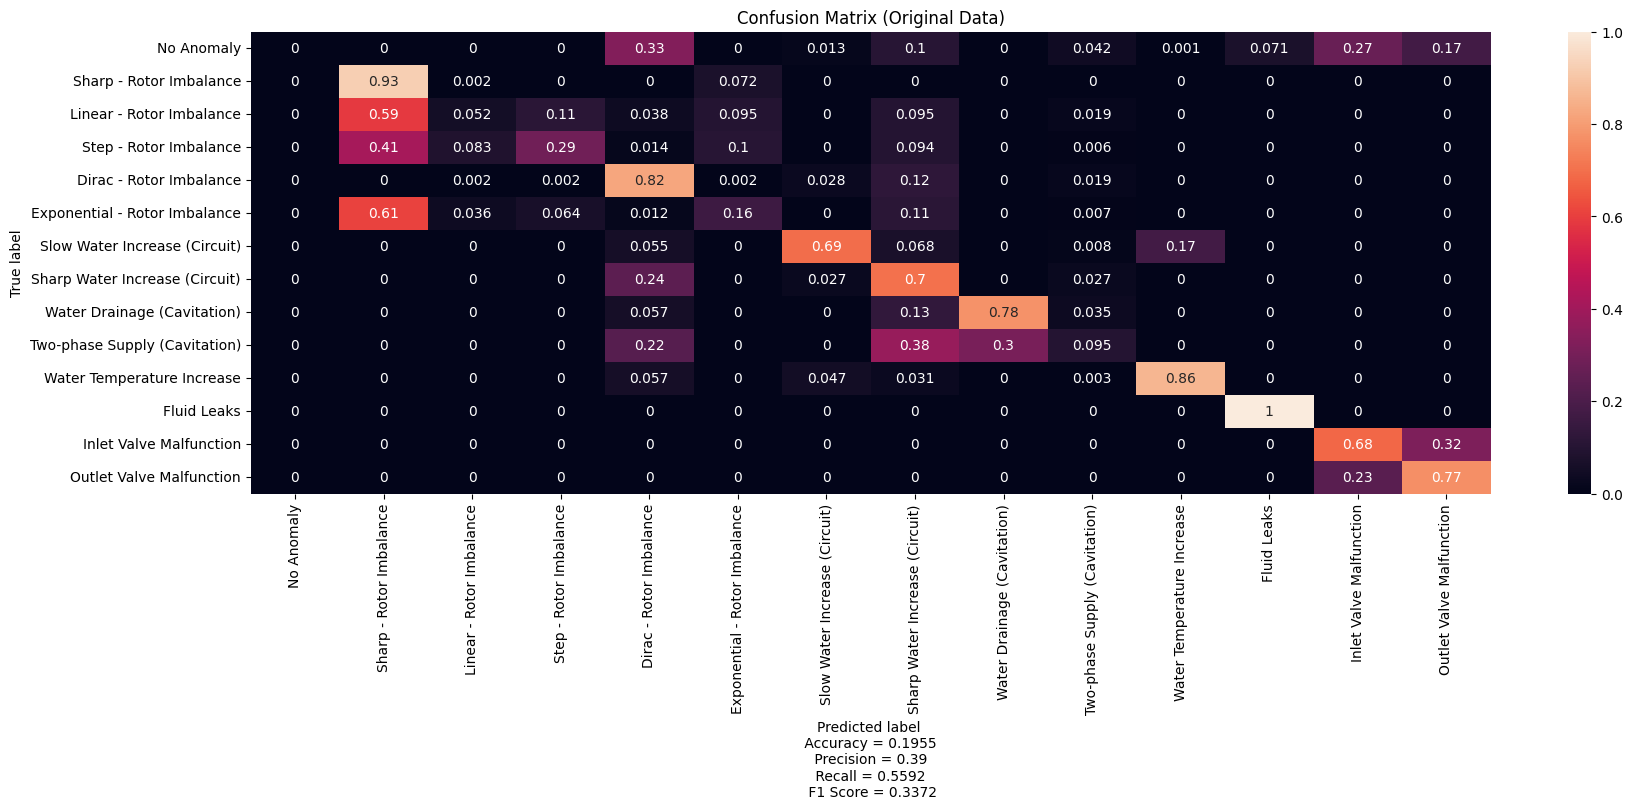

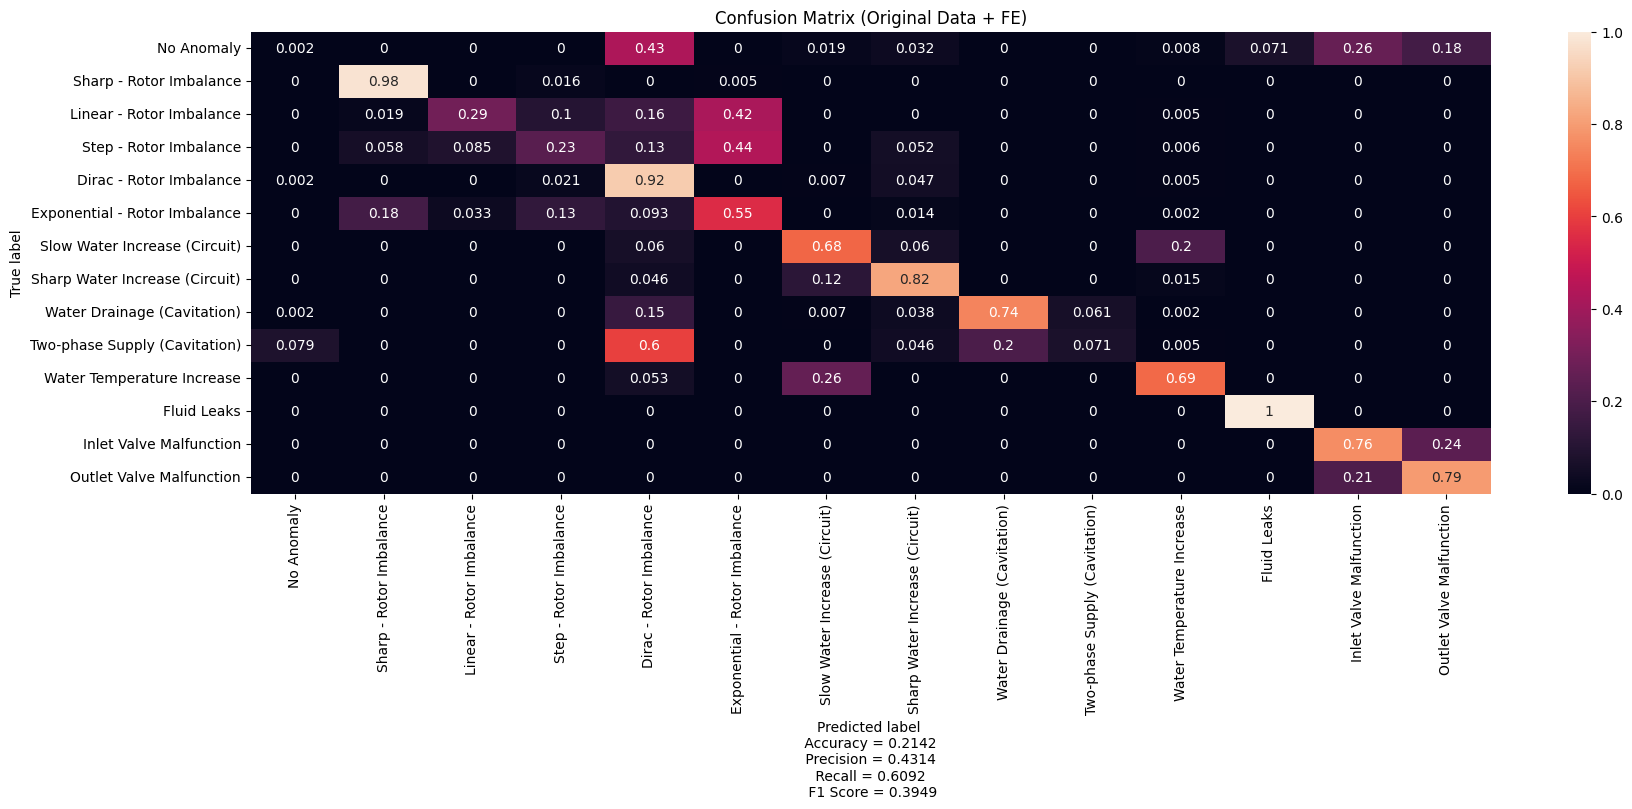

In [25]:
get_confusion_matrix(dataframe_X_og_pred, anomaly_names, title="Confusion Matrix (Original Data)")
get_confusion_matrix(dataframe_X_og_fe_pred, anomaly_names, title="Confusion Matrix (Original Data + FE)")

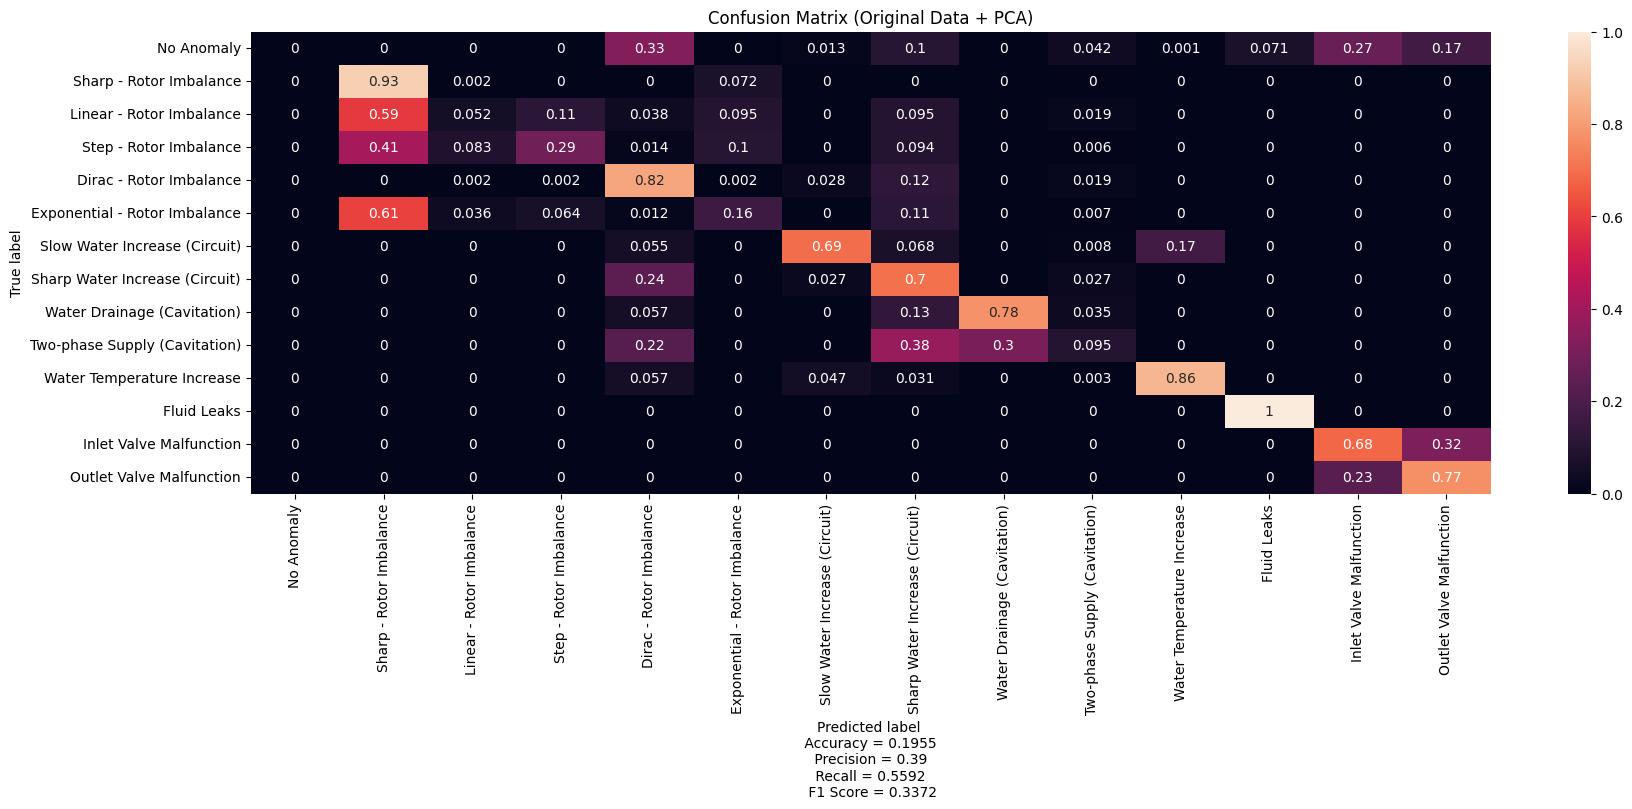

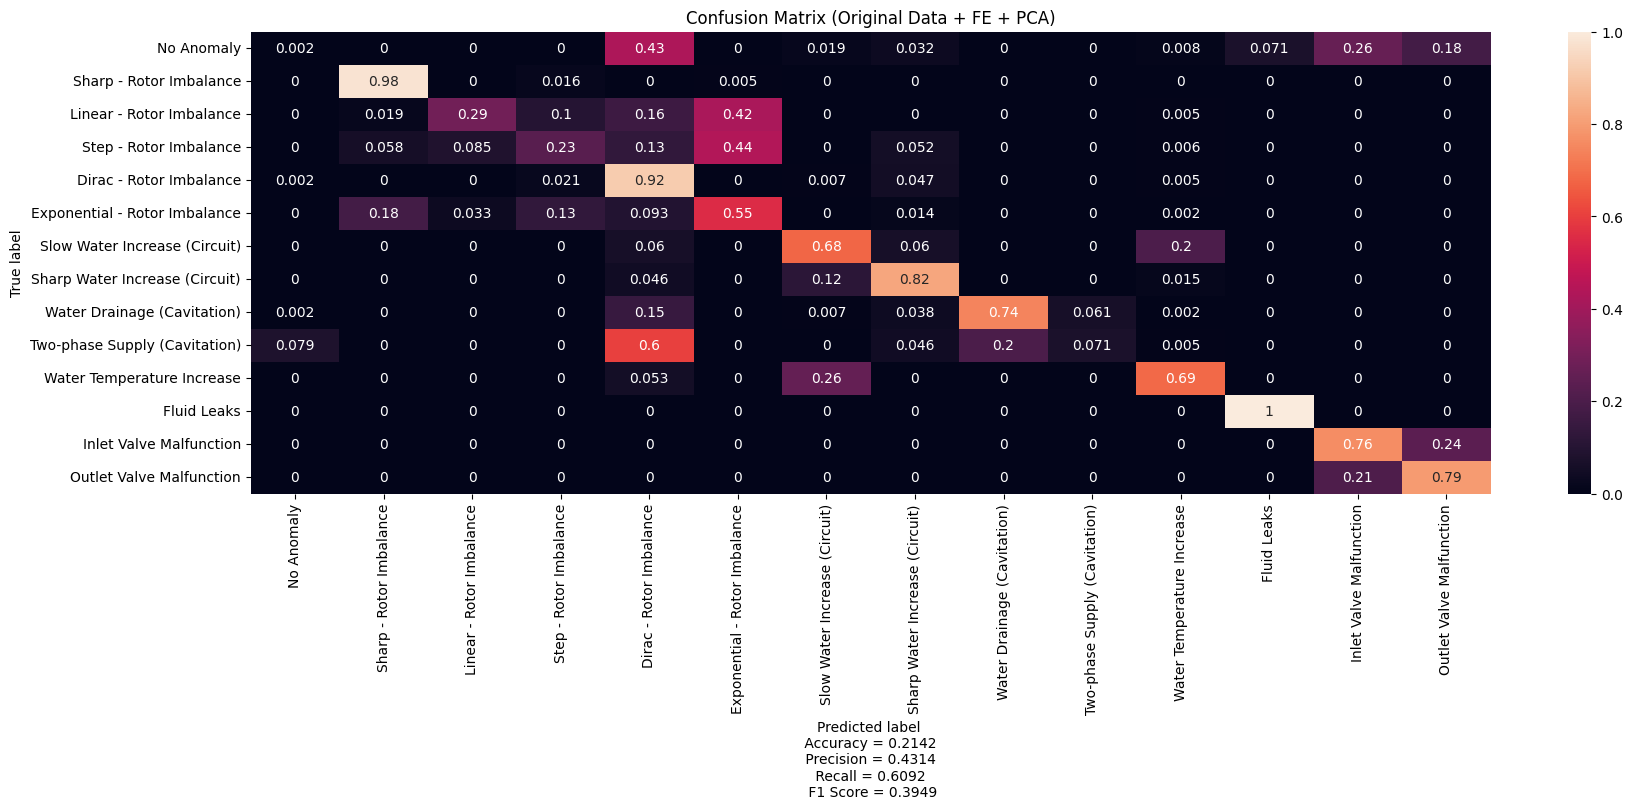

In [26]:
get_confusion_matrix(dataframe_X_og_pca_pred, anomaly_names, title="Confusion Matrix (Original Data + PCA)")
get_confusion_matrix(dataframe_X_og_fe_pca_pred, anomaly_names, title="Confusion Matrix (Original Data + FE + PCA)")

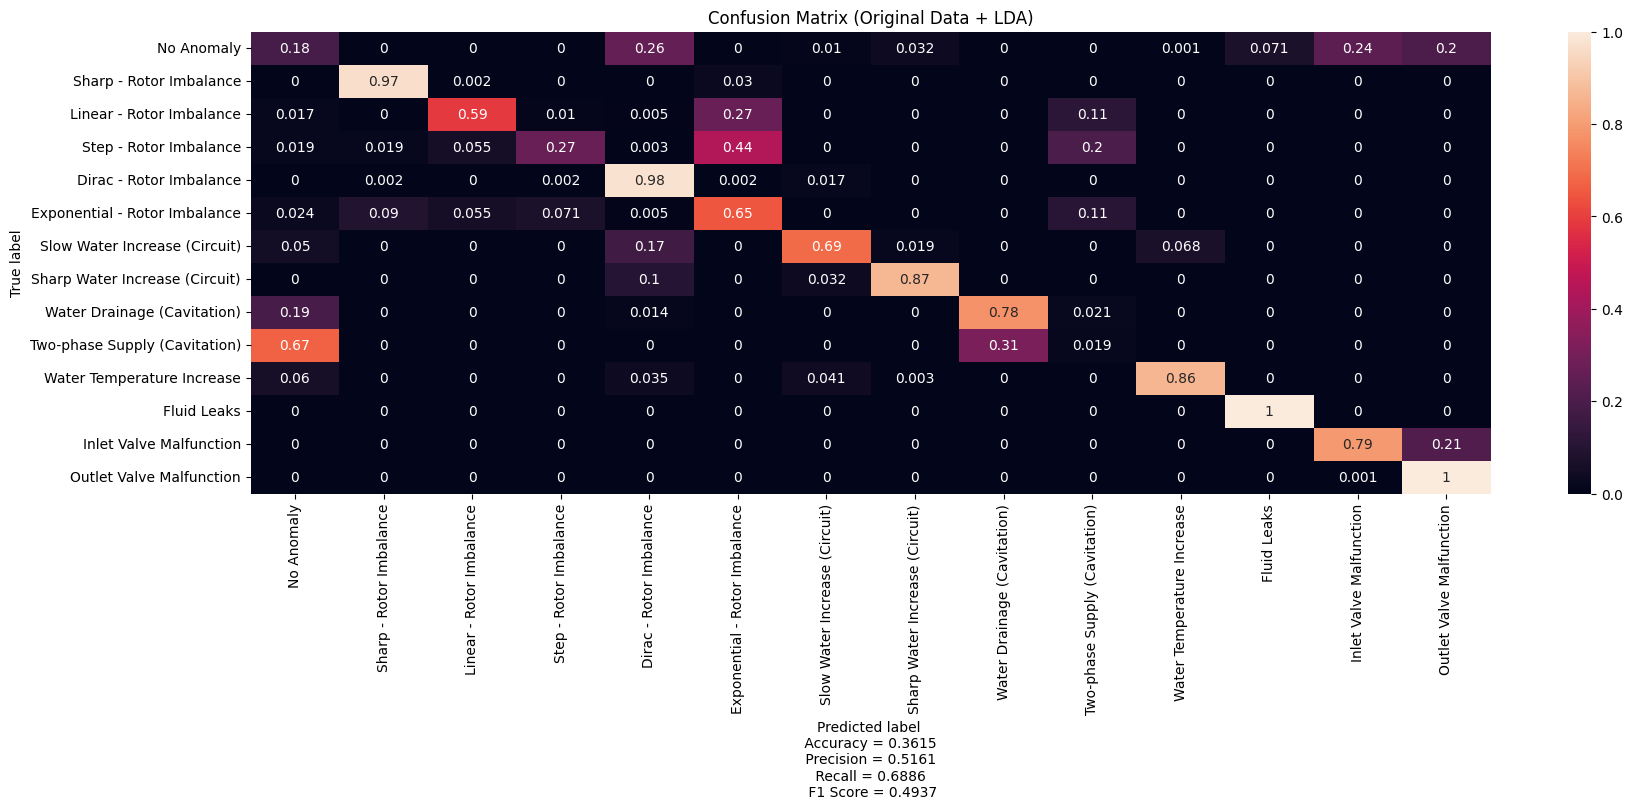

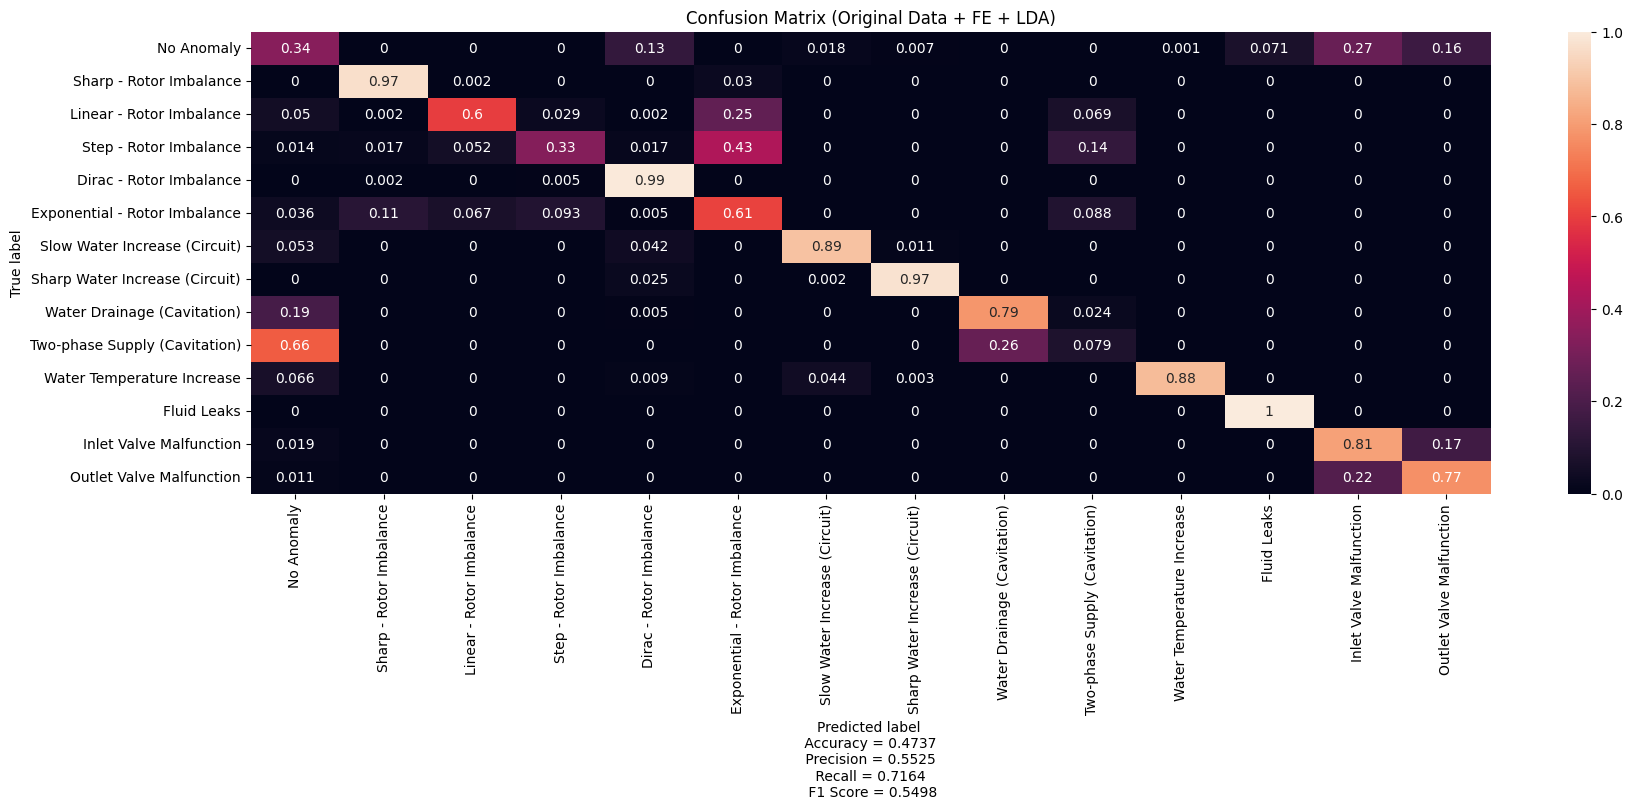

In [27]:
get_confusion_matrix(dataframe_X_og_lda_pred, anomaly_names, title="Confusion Matrix (Original Data + LDA)")
get_confusion_matrix(dataframe_X_og_fe_lda_pred, anomaly_names, title="Confusion Matrix (Original Data + FE + LDA)")

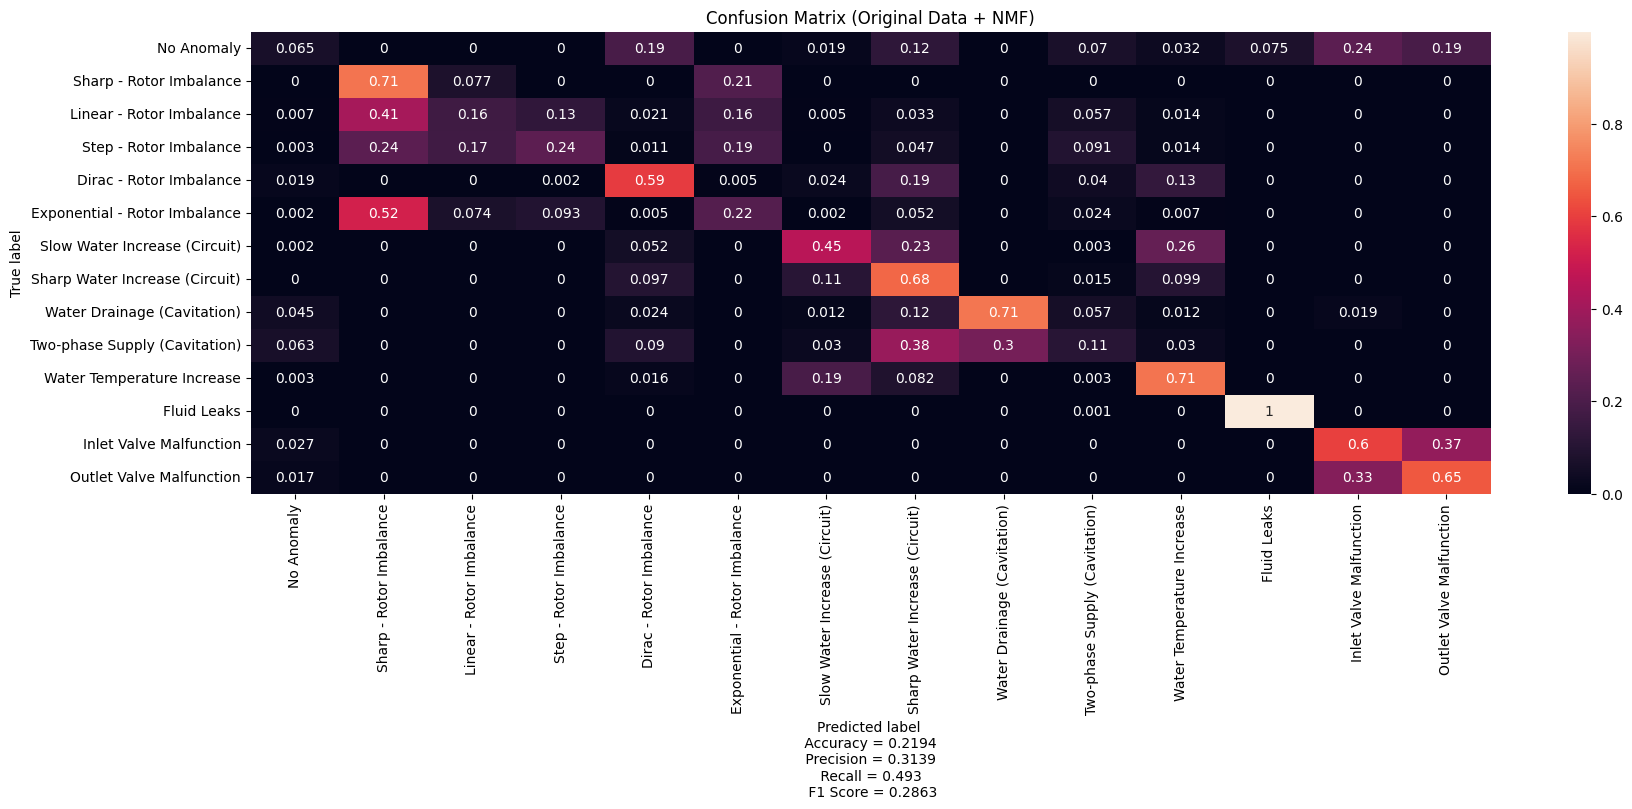

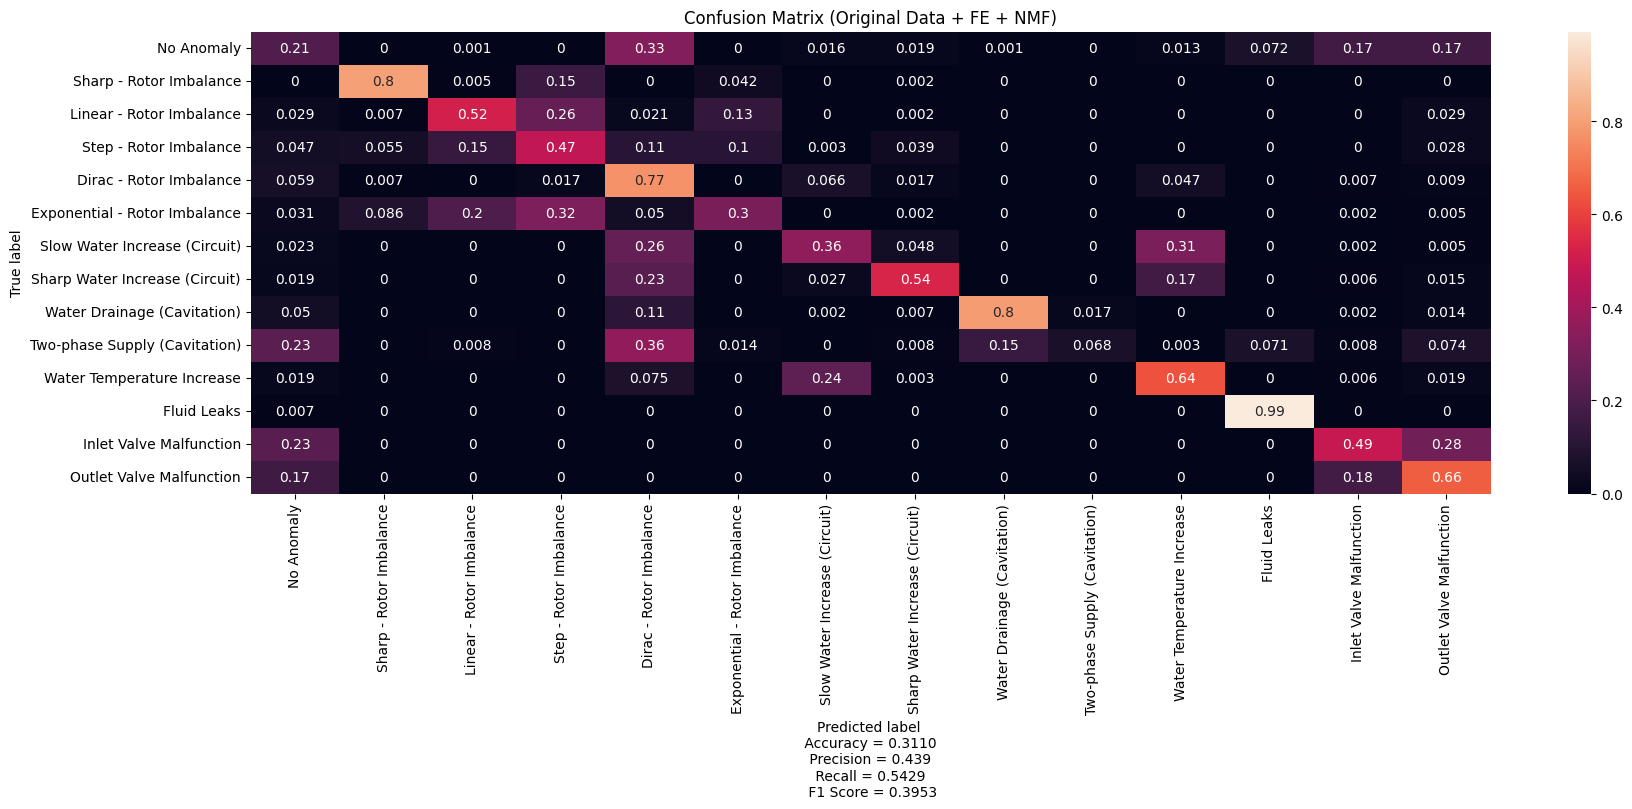

In [28]:
get_confusion_matrix(dataframe_X_og_nmf_pred, anomaly_names, title="Confusion Matrix (Original Data + NMF)")
get_confusion_matrix(dataframe_X_og_fe_nmf_pred, anomaly_names, title="Confusion Matrix (Original Data + FE + NMF)")